# Cherry-Pick Patch Explorer

**Workflow**

1. **Scan & audit** — probe every `.zarr` product in `data/` and build a product inventory (`data/product_catalog.json` / `.csv`). No data is loaded.
2. **Explore** — pick one usable product and display a full subsampled overview. Non-downloaded chunks appear dark (zarr returns fill value 0+0j for missing chunks).
3. **Select a patch** — set azimuth / range coordinates and inspect the zoom-in.
4. **Save** — write the selection to `data/selected_patch.json` for use in the F14 fixed-patch callback.

> **Colour convention**: log-intensity `logI = ln(re² + im² + ε)`, clipped `mean ± 3σ`, colourmap `viridis`. Raw real/imag and linear amplitude are never displayed directly.


## 1 · Import Required Libraries

In [14]:
import gc
import json
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zarr
import rootutils

# ── Project root (works regardless of cwd) ──────────────────────────────────
root = rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)
DATA_DIR = root / "data"

# ── Project utilities ────────────────────────────────────────────────────────
from maya4.utils import get_zarr_version, parse_product_filename
from src.utils.processing_utils import scan_available_data_extent
from src.utils.visualization_utils import find_optimal_step_size

EPS = 1e-2  # for log-intensity: logI = ln(re² + im² + EPS)

print(f"Project root : {root}")
print(f"Data dir     : {DATA_DIR}")


Project root : /mnt/vitisAI/Vitis-AI/MAYA_DC
Data dir     : /mnt/vitisAI/Vitis-AI/MAYA_DC/data


## 2 · Scan Local Zarr Products

Find every `.zarr` directory under `data/` recursively.

In [15]:
# Collect every top-level *.zarr directory (non-recursive at the .zarr level)
# rglob("*.zarr") would also descend into rcmc/, az/ sub-stores — avoid that
# by filtering to paths whose parent does NOT itself end in .zarr.
all_zarr = sorted(
    p for p in DATA_DIR.rglob("*.zarr")
    if not any(part.endswith(".zarr") for part in p.parent.parts)
)

print(f"Found {len(all_zarr)} top-level .zarr products")
for p in all_zarr:
    rel = p.relative_to(DATA_DIR)
    print(f"  {rel}")


Found 126 top-level .zarr products
  PT1/.cache/huggingface/download/s1a-s1-raw-s-hh-20230508t121142-20230508t121213-048442-05d3c0.zarr
  PT1/.cache/huggingface/download/s1a-s1-raw-s-hh-20230731t121147-20230731t121217-049667-05f8f1.zarr
  PT1/.cache/huggingface/download/s1a-s2-raw-s-hh-20230618t213535-20230618t213600-049046-05e5da.zarr
  PT1/.cache/huggingface/download/s1a-s2-raw-s-hh-20230817t213538-20230817t213604-049921-06013c.zarr
  PT1/.cache/huggingface/download/s1a-s2-raw-s-hh-20231004t213540-20231004t213605-050621-061929.zarr
  PT1/.cache/huggingface/download/s1a-s2-raw-s-hh-20231121t213539-20231121t213605-051321-063134.zarr
  PT1/.cache/huggingface/download/s1a-s3-raw-s-hh-20230331t213600-20230331t213625-047893-05c14a.zarr
  PT1/.cache/huggingface/download/s1a-s3-raw-s-hh-20230703t000114-20230703t000135-049251-05ec1d.zarr
  PT1/.cache/huggingface/download/s1a-s3-raw-s-hh-20230818t153559-20230818t153615-049931-06019e.zarr
  PT1/.cache/huggingface/download/s1a-s3-raw-s-hh-202309

## 3 · Validate Metadata, Ephemeris & Download Completeness

For each product we probe:
- **`has_metadata` / `has_ephemeris`** — keys present in the zarr root attributes. Products missing either cannot be used for azimuth compression.
- **`can_open`** — the zarr group opens without error. `False` usually means metadata-only download (no chunk files).
- **`download_fraction`** — fraction of the full image covered by downloaded chunks (via `scan_available_data_extent`). `0.0` or `None` means no data at all.

No pixel data is loaded during the scan.

In [ ]:
def scan_one_product(zpath: Path) -> dict | None:
    """
    Probe a single zarr product.
    Returns a dict of its properties, or None if the filename is not a
    recognised Sentinel-1 product name.
    No pixel data is loaded — only filesystem metadata and zarr .zarray files.
    """
    rec = parse_product_filename(zpath)
    if rec is None:
        return None  # not a Sentinel-1 zarr

    entry: dict = {
        # ── Identity ──────────────────────────────────────────────────────
        "file":          zpath.name,
        "full_path":     str(zpath),
        "part":          rec["part"],
        "date":          rec["acquisition_date"].strftime("%Y-%m-%d"),
        "year":          rec["acquisition_date"].year,
        "month":         rec["acquisition_date"].month,
        "stripmap_mode": int(rec["stripmap_mode"]),
        "polarization":  rec["polarization"],
        # ── Zarr store ────────────────────────────────────────────────────
        "zarr_version":  None,     # int: 2 or 3
        "has_rcmc_dir":  (zpath / "rcmc").exists(),
        "has_az_dir":    (zpath / "az").exists(),
        "can_open":      False,    # zarr group openable without error
        "has_metadata":  False,    # 'metadata' key present AND has data rows
        "has_ephemeris": False,    # 'ephemeris' key present AND has data rows
        # ── Array geometry (from zarr JSON, no data load) ─────────────────
        "rcmc_shape":    None,     # [Az, Rg]
        "rcmc_chunks":   None,     # [chunk_az, chunk_rg]
        # ── Download completeness ──────────────────────────────────────────
        "az_downloaded": None,     # [start, stop] in azimuth lines
        "rg_downloaded": None,     # [start, stop] in range samples
        "download_fraction": None, # float in [0, 1]; None = could not determine
        # ── Derived ───────────────────────────────────────────────────────
        "is_usable":     False,    # can_open + has_metadata + has_ephemeris + data present
    }

    # ── Zarr version ──────────────────────────────────────────────────────────
    try:
        entry["zarr_version"] = get_zarr_version(zpath)
    except ValueError:
        pass

    # ── Open group and read attributes ────────────────────────────────────────
    if entry["has_rcmc_dir"]:
        try:
            store = zarr.open(str(zpath), mode="r")
            entry["can_open"] = True
            # has_metadata / has_ephemeris = True only when the key exists AND
            # at least one data row is present.  Some products (e.g. FOCUSED)
            # have the key but store zero rows -- those cannot be used for
            # azimuth compression and must be flagged as not usable.
            if "metadata" in store.attrs:
                _m = store.attrs["metadata"]
                _rows = _m.get("data", []) if isinstance(_m, dict) else []
                entry["has_metadata"] = len(_rows) > 0
            if "ephemeris" in store.attrs:
                _e = store.attrs["ephemeris"]
                _rows = _e.get("data", []) if isinstance(_e, dict) else []
                entry["has_ephemeris"] = len(_rows) > 0
            if "rcmc" in store:
                arr = store["rcmc"]
                entry["rcmc_shape"]  = list(arr.shape)
                entry["rcmc_chunks"] = list(arr.chunks)
            del store
            gc.collect()
        except Exception as exc:
            # Common cause: metadata-only download (no chunk files present)
            entry["_open_error"] = str(exc)

    # ── Downloaded extent (filesystem walk, no data load) ─────────────────────
    if entry["can_open"] and entry["rcmc_shape"] is not None:
        try:
            az_sl, rg_sl = scan_available_data_extent(zpath, "rcmc")
            entry["az_downloaded"] = [az_sl.start, az_sl.stop]
            entry["rg_downloaded"] = [rg_sl.start, rg_sl.stop]
            dl_px    = (az_sl.stop - az_sl.start) * (rg_sl.stop - rg_sl.start)
            total_px = entry["rcmc_shape"][0] * entry["rcmc_shape"][1]
            entry["download_fraction"] = round(dl_px / total_px, 4)
        except Exception:
            # No chunks downloaded at all, or non-contiguous layout
            entry["download_fraction"] = 0.0

    # ── Usability flag ────────────────────────────────────────────────────────
    entry["is_usable"] = bool(
        entry["can_open"]
        and entry["has_metadata"]
        and entry["has_ephemeris"]
        and entry["has_rcmc_dir"]
        and entry["has_az_dir"]
        and (entry["download_fraction"] or 0.0) > 0.0
    )

    return entry


In [17]:
# ── Run the scan ──────────────────────────────────────────────────────────────
catalog: list[dict] = []
skipped = 0

for i, zp in enumerate(all_zarr):
    print(f"[{i+1:2d}/{len(all_zarr)}] {zp.name[:70]}", end=" ... ")
    entry = scan_one_product(zp)
    if entry is None:
        print("skip (not a S1 product name)")
        skipped += 1
        continue
    status = "✓ usable" if entry["is_usable"] else (
        "✗ no metadata/ephemeris" if entry["can_open"] and not (entry["has_metadata"] and entry["has_ephemeris"])
        else "✗ cannot open"        if not entry["can_open"]
        else "✗ no data downloaded"
    )
    dl_pct = f"{100*entry['download_fraction']:.1f}%" if entry["download_fraction"] is not None else "—"
    print(f"{status}  [dl={dl_pct}]")
    catalog.append(entry)

print(f"\nScanned {len(catalog)} products ({skipped} skipped). "
      f"{sum(e['is_usable'] for e in catalog)} usable.")


[ 1/126] s1a-s1-raw-s-hh-20230508t121142-20230508t121213-048442-05d3c0.zarr ... ✗ cannot open  [dl=—]
[ 2/126] s1a-s1-raw-s-hh-20230731t121147-20230731t121217-049667-05f8f1.zarr ... ✗ cannot open  [dl=—]
[ 3/126] s1a-s2-raw-s-hh-20230618t213535-20230618t213600-049046-05e5da.zarr ... ✗ cannot open  [dl=—]
[ 4/126] s1a-s2-raw-s-hh-20230817t213538-20230817t213604-049921-06013c.zarr ... ✗ cannot open  [dl=—]
[ 5/126] s1a-s2-raw-s-hh-20231004t213540-20231004t213605-050621-061929.zarr ... ✗ cannot open  [dl=—]
[ 6/126] s1a-s2-raw-s-hh-20231121t213539-20231121t213605-051321-063134.zarr ... ✗ cannot open  [dl=—]
[ 7/126] s1a-s3-raw-s-hh-20230331t213600-20230331t213625-047893-05c14a.zarr ... ✗ cannot open  [dl=—]
[ 8/126] s1a-s3-raw-s-hh-20230703t000114-20230703t000135-049251-05ec1d.zarr ... ✗ cannot open  [dl=—]
[ 9/126] s1a-s3-raw-s-hh-20230818t153559-20230818t153615-049931-06019e.zarr ... ✗ cannot open  [dl=—]
[10/126] s1a-s3-raw-s-hh-20230915t213608-20230915t213634-050343-060fae.zarr ... ✗ 

## 4 · Build Product Inventory DataFrame

In [18]:
df = pd.DataFrame(catalog)

# Derived display columns
DISPLAY_COLS = [
    "file", "part", "date", "stripmap_mode", "polarization",
    "zarr_version", "can_open", "has_metadata", "has_ephemeris",
    "rcmc_shape", "rcmc_chunks", "download_fraction", "is_usable",
]

def _row_style(row: pd.Series) -> list[str]:
    """Green = usable | Yellow = open but incomplete | Red = cannot open."""
    if row["is_usable"]:
        bg = "background-color: #d4edda; color: #155724"   # green
    elif row.get("can_open", False):
        bg = "background-color: #fff3cd; color: #856404"   # yellow
    else:
        bg = "background-color: #f8d7da; color: #721c24"   # red
    return [bg] * len(row)

df[DISPLAY_COLS].style.apply(_row_style, axis=1).format(
    {"download_fraction": lambda v: f"{100*v:.1f}%" if v is not None else "—"}
)


,file,part,date,stripmap_mode,polarization,zarr_version,can_open,has_metadata,has_ephemeris,rcmc_shape,rcmc_chunks,download_fraction,is_usable
0,s1a-s1-raw-s-hh-20230508t121142-20230508t121213-048442-05d3c0.zarr,download,2023-05-08,1,hh,nan,False,False,False,None,None,nan%,False
1,s1a-s1-raw-s-hh-20230731t121147-20230731t121217-049667-05f8f1.zarr,download,2023-07-31,1,hh,nan,False,False,False,None,None,nan%,False
2,s1a-s2-raw-s-hh-20230618t213535-20230618t213600-049046-05e5da.zarr,download,2023-06-18,2,hh,nan,False,False,False,None,None,nan%,False
3,s1a-s2-raw-s-hh-20230817t213538-20230817t213604-049921-06013c.zarr,download,2023-08-17,2,hh,nan,False,False,False,None,None,nan%,False
4,s1a-s2-raw-s-hh-20231004t213540-20231004t213605-050621-061929.zarr,download,2023-10-04,2,hh,nan,False,False,False,None,None,nan%,False
5,s1a-s2-raw-s-hh-20231121t213539-20231121t213605-051321-063134.zarr,download,2023-11-21,2,hh,nan,False,False,False,None,None,nan%,False
6,s1a-s3-raw-s-hh-20230331t213600-20230331t213625-047893-05c14a.zarr,download,2023-03-31,3,hh,nan,False,False,False,None,None,nan%,False
7,s1a-s3-raw-s-hh-20230703t000114-20230703t000135-049251-05ec1d.zarr,download,2023-07-03,3,hh,nan,False,False,False,None,None,nan%,False
8,s1a-s3-raw-s-hh-20230818t153559-20230818t153615-049931-06019e.zarr,download,2023-08-18,3,hh,nan,False,False,False,None,None,nan%,False
9,s1a-s3-raw-s-hh-20230915t213608-20230915t213634-050343-060fae.zarr,download,2023-09-15,3,hh,nan,False,False,False,None,None,nan%,False


## 5 · Export Inventory to JSON and CSV

Saves `data/product_catalog.json` and `data/product_catalog.csv`.
Downstream scripts can load either file to quickly filter usable products without re-scanning.

In [19]:
json_path = DATA_DIR / "product_catalog.json"
csv_path  = DATA_DIR / "product_catalog.csv"

# JSON — preserves lists (rcmc_shape, rcmc_chunks, az_downloaded, rg_downloaded)
with open(json_path, "w") as fh:
    json.dump(catalog, fh, indent=2, default=str)

# CSV — lists are serialised as strings; easy to open in a spreadsheet
df.to_csv(csv_path, index=False)

print(f"✓ Saved {len(catalog)} entries")
print(f"  JSON → {json_path.relative_to(root)}")
print(f"  CSV  → {csv_path.relative_to(root)}")
print()
print("Quick-load snippet for other scripts:")
print("  import json")
print("  catalog = json.load(open('data/product_catalog.json'))")
print("  usable  = [e for e in catalog if e['is_usable']]")


✓ Saved 124 entries
  JSON → data/product_catalog.json
  CSV  → data/product_catalog.csv

Quick-load snippet for other scripts:
  import json
  catalog = json.load(open('data/product_catalog.json'))
  usable  = [e for e in catalog if e['is_usable']]


## 6 · Visualise Product Audit Summary

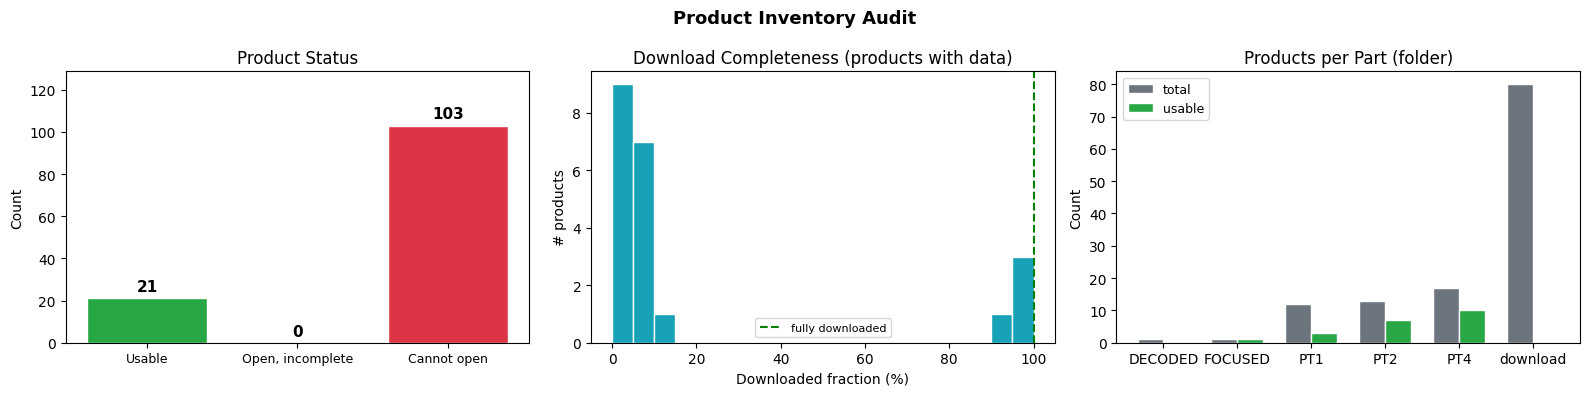

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── 1 · Valid / Invalid count ─────────────────────────────────────────────────
ax = axes[0]
status_counts = {
    "Usable":            sum(e["is_usable"] for e in catalog),
    "Open, incomplete":  sum(not e["is_usable"] and e["can_open"] for e in catalog),
    "Cannot open":       sum(not e["can_open"] for e in catalog),
}
colours = ["#28a745", "#ffc107", "#dc3545"]
bars = ax.bar(status_counts.keys(), status_counts.values(), color=colours, edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=11, fontweight="bold")
ax.set_title("Product Status")
ax.set_ylabel("Count")
ax.set_ylim(0, max(status_counts.values()) * 1.25)
ax.tick_params(axis="x", labelsize=9)

# ── 2 · Download fraction histogram ───────────────────────────────────────────
ax = axes[1]
dl_vals = [
    100 * e["download_fraction"]
    for e in catalog
    if e["download_fraction"] is not None and e["download_fraction"] > 0
]
if dl_vals:
    ax.hist(dl_vals, bins=20, range=(0, 100), color="#17a2b8", edgecolor="white")
ax.axvline(100, color="green", linestyle="--", linewidth=1.5, label="fully downloaded")
ax.set_title("Download Completeness (products with data)")
ax.set_xlabel("Downloaded fraction (%)")
ax.set_ylabel("# products")
ax.legend(fontsize=8)

# ── 3 · Products by part ──────────────────────────────────────────────────────
ax = axes[2]
part_counts = df.groupby("part")["is_usable"].agg(
    usable="sum",
    total="count",
).reset_index()
x = np.arange(len(part_counts))
w = 0.35
ax.bar(x - w/2, part_counts["total"],  w, label="total",  color="#6c757d", edgecolor="white")
ax.bar(x + w/2, part_counts["usable"], w, label="usable", color="#28a745", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(part_counts["part"])
ax.set_title("Products per Part (folder)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.suptitle("Product Inventory Audit", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 7 · Explore a Product

**Instructions:**
1. Copy a `full_path` value from the green rows in Section 4 above.
2. Paste it as `SELECTED_FILE` in the cell below (relative to the project root).
3. Run the cell to display the full subsampled overview.

> **Black regions** in the image are **non-downloaded chunks** (zarr returns `0+0j` for missing chunks in offline mode — they display as black after logI). The ◼ lime rectangle marks the downloaded extent; ◻ dashed-red marks the full image boundary.
>
> **Display orientation** (SAR convention): **(0, 0) is at the top-left**. Azimuth is **horizontal, left → right** (Az=0 at the left). Range is **vertical, top → bottom** (Rg=0 at the top). This matches a satellite flying left-to-right above the scene.


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# ✏  EDIT THIS — paste the full_path from a green row above
# ══════════════════════════════════════════════════════════════════════════════
SELECTED_FILE = "data/TEST/FOCUSED/s1a-s6-raw-s-vh-20240502t195132-20240502t195153-053697-0685cc.zarr"
# SELECTED_FILE = "data/PT4/s1a-s1-raw-s-hh-20230511t151235-20230511t151251-048487-05d521.zarr"
# ══════════════════════════════════════════════════════════════════════════════

zpath = root / SELECTED_FILE

# Retrieve catalog entry for this product (if scanned above)
_matches = [e for e in catalog if e["full_path"] == str(zpath)]
_entry   = _matches[0] if _matches else {}
print(f"Product  : {zpath.name}")
print(f"Part     : {_entry.get('part', '?')}")
print(f"Date     : {_entry.get('date', '?')}")
print(f"Metadata : {_entry.get('has_metadata', '?')}   Ephemeris: {_entry.get('has_ephemeris', '?')}")
print(f"Shape    : {_entry.get('rcmc_shape', '?')}   Chunks: {_entry.get('rcmc_chunks', '?')}")
print(f"Download : {100*_entry['download_fraction']:.1f}%" if _entry.get("download_fraction") else "Download : —")

if _entry and not _entry.get("is_usable"):
    print("\n⚠  This product is NOT fully usable (missing metadata, ephemeris, or data).")
    print("   Visualisation will still proceed but azimuth compression will fail.")


Product  : s1a-s6-raw-s-vh-20240502t195132-20240502t195153-053697-0685cc.zarr
Part     : FOCUSED
Date     : 2024-05-02
Metadata : True   Ephemeris: True
Shape    : [33260, 20078]   Chunks: [4096, 4096]
Download : 100.0%


Full image shape : 33260 Az × 20078 Rg
Downloaded Az : [0 : 33260]  (33260 lines)
Downloaded Rg : [0 : 20078]  (20078 samples)

Subsampling step : 47  →  display size ~ 707 × 427 px


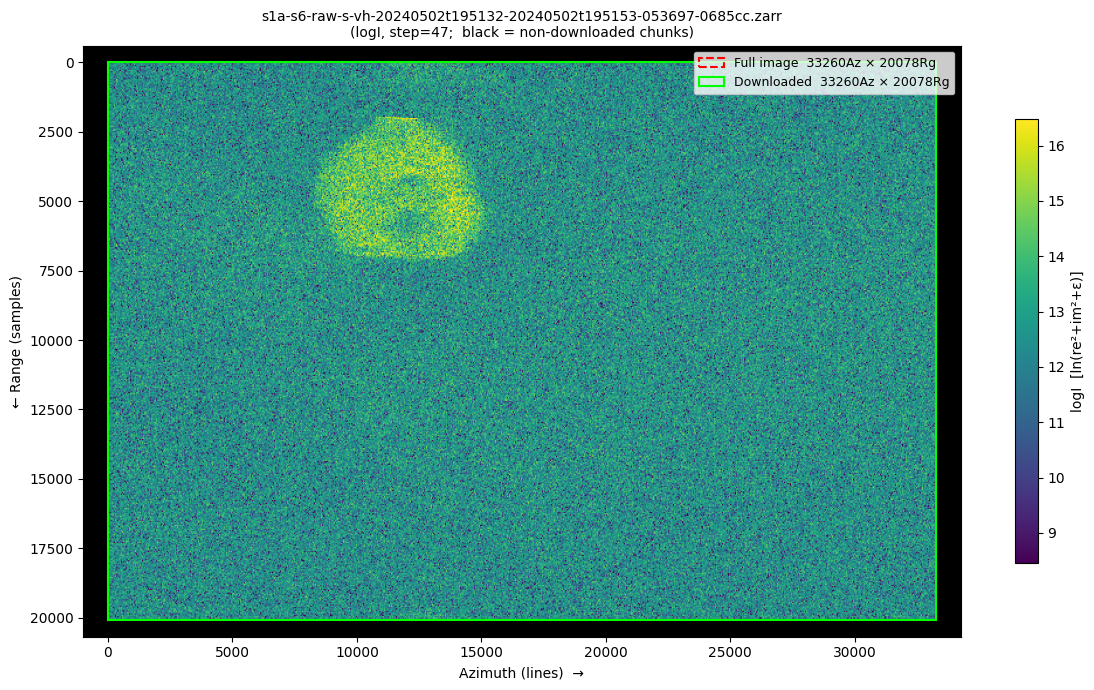

In [22]:
OVERVIEW_TARGET_PX = 700   # target pixel size for display (shorter axis)

# ── Open array (lazy, no data load) ──────────────────────────────────────────
_store    = zarr.open(str(zpath), mode="r")
store_rcmc = _store["rcmc"]         # keep open for patch zoom later
full_az, full_rg = store_rcmc.shape
print(f"Full image shape : {full_az} Az × {full_rg} Rg")

# ── Downloaded extent ─────────────────────────────────────────────────────────
try:
    _az_sl, _rg_sl = scan_available_data_extent(zpath, "rcmc")
    az_dl_start, az_dl_stop = _az_sl.start, _az_sl.stop
    rg_dl_start, rg_dl_stop = _rg_sl.start, _rg_sl.stop
    print(f"Downloaded Az : [{az_dl_start} : {az_dl_stop}]  ({az_dl_stop - az_dl_start} lines)")
    print(f"Downloaded Rg : [{rg_dl_start} : {rg_dl_stop}]  ({rg_dl_stop - rg_dl_start} samples)")
except Exception as exc:
    print(f"⚠  Could not determine downloaded extent: {exc}")
    az_dl_start, az_dl_stop = 0, full_az
    rg_dl_start, rg_dl_stop = 0, full_rg

az_dl = az_dl_stop - az_dl_start
rg_dl = rg_dl_stop - rg_dl_start

# ── Subsample (only within downloaded region) ─────────────────────────────────
_step = find_optimal_step_size(az_dl, rg_dl, OVERVIEW_TARGET_PX)
print(f"\nSubsampling step : {_step}  →  display size ~ {az_dl//_step} × {rg_dl//_step} px")

_patch = store_rcmc[az_dl_start : az_dl_stop : _step,
                    rg_dl_start : rg_dl_stop : _step]

logI_overview = np.log(np.real(_patch)**2 + np.imag(_patch)**2 + EPS)
ov_mu, ov_sigma = logI_overview.mean(), logI_overview.std()
ov_vmin, ov_vmax = ov_mu - 3 * ov_sigma, ov_mu + 3 * ov_sigma
del _patch
gc.collect()

# ── Plot ──────────────────────────────────────────────────────────────────────
# SAR display convention:
#   • (0, 0) at the top-left corner
#   • Azimuth = horizontal, left → right (Az=0 at the left edge)
#   • Range   = vertical,   top  → bottom (Rg=0 at the top edge)
# Array is (Az, Rg). Transpose to (Rg, Az) so matplotlib's x=Az, y=Rg.
# extent=[x_left, x_right, y_bottom, y_top]; y_bottom > y_top → Rg grows downward.
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor("black")   # non-downloaded regions appear black

im = ax.imshow(
    logI_overview.T,          # shape (Rg_sub, Az_sub): x=Az, y=Rg
    cmap="viridis",
    vmin=ov_vmin, vmax=ov_vmax,
    origin="upper",
    extent=[az_dl_start, az_dl_stop, rg_dl_stop, rg_dl_start],
    aspect="auto",
)
plt.colorbar(im, ax=ax, label="logI  [ln(re²+im²+ε)]", shrink=0.75)

# Rectangles: corner = (az_corner, rg_corner), width = az_extent, height = rg_extent
ax.add_patch(mpatches.Rectangle(
    (0, 0), full_az, full_rg,
    fill=False, edgecolor="red", linewidth=1.5, linestyle="--",
    label=f"Full image  {full_az}Az × {full_rg}Rg",
))
ax.add_patch(mpatches.Rectangle(
    (az_dl_start, rg_dl_start), az_dl, rg_dl,
    fill=False, edgecolor="lime", linewidth=1.5, linestyle="-",
    label=f"Downloaded  {az_dl}Az × {rg_dl}Rg",
))

# Az=0 at the left (no inversion); Rg=0 at the top (y_bottom > y_top via extent)
ax.set_xlim(-full_az * 0.03, full_az * 1.03)
ax.set_ylim(full_rg * 1.03, -full_rg * 0.03)
ax.set_xlabel("Azimuth (lines)  →")
ax.set_ylabel("← Range (samples)")   # label rotated 90° CCW: ← appears as ↓ on screen
ax.set_title(
    f"{zpath.name}\n"
    f"(logI, step={_step};  black = non-downloaded chunks)",
    fontsize=10,
)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


---
## 8 · Select a Patch

1. Look at the overview above and identify a good area — avoid black (non-downloaded) regions and image borders.
2. Edit `AZ_START`, `AZ_END`, `RG_START`, `RG_END` in the cell below.
3. Run both remaining cells: the first shows your patch on the overview (black box); the second saves the coordinates.


In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# ✏  EDIT THESE — coordinates in original image pixels
# ══════════════════════════════════════════════════════════════════════════════
WANTED_PATCH_SIZE = 2048
AZ_START = az_dl_start + 11_000
AZ_END   = AZ_START + WANTED_PATCH_SIZE
RG_START = rg_dl_start + 5_500
RG_END   = RG_START + WANTED_PATCH_SIZE
# AZ_START = az_dl_start + az_dl // 4        # azimuth start (lines)
# AZ_END   = az_dl_start + 3 * az_dl // 4   # azimuth end   (lines)
# RG_START = rg_dl_start + rg_dl // 4        # range start   (samples)
# RG_END   = rg_dl_start + 3 * rg_dl // 4   # range end     (samples)
# ══════════════════════════════════════════════════════════════════════════════

az_patch = AZ_END - AZ_START
rg_patch = RG_END - RG_START
print(f"Selected patch : Az [{AZ_START} : {AZ_END}] × Rg [{RG_START} : {RG_END}]")
print(f"Patch size     : {az_patch} Az-lines × {rg_patch} Rg-samples")

# ── Sanity checks ─────────────────────────────────────────────────────────────
ok = True
if AZ_START < az_dl_start or AZ_END > az_dl_stop:
    print(f"⚠  Azimuth range [{AZ_START}:{AZ_END}] is outside downloaded region "
          f"[{az_dl_start}:{az_dl_stop}]")
    ok = False
if RG_START < rg_dl_start or RG_END > rg_dl_stop:
    print(f"⚠  Range range [{RG_START}:{RG_END}] is outside downloaded region "
          f"[{rg_dl_start}:{rg_dl_stop}]")
    ok = False
if az_patch <= 0 or rg_patch <= 0:
    print("⚠  Patch has zero or negative size. Check AZ/RG values.")
    ok = False
if ok:
    print("✓ Patch is within the downloaded region.")


Selected patch : Az [11000 : 13048] × Rg [5500 : 7548]
Patch size     : 2048 Az-lines × 2048 Rg-samples
✓ Patch is within the downloaded region.


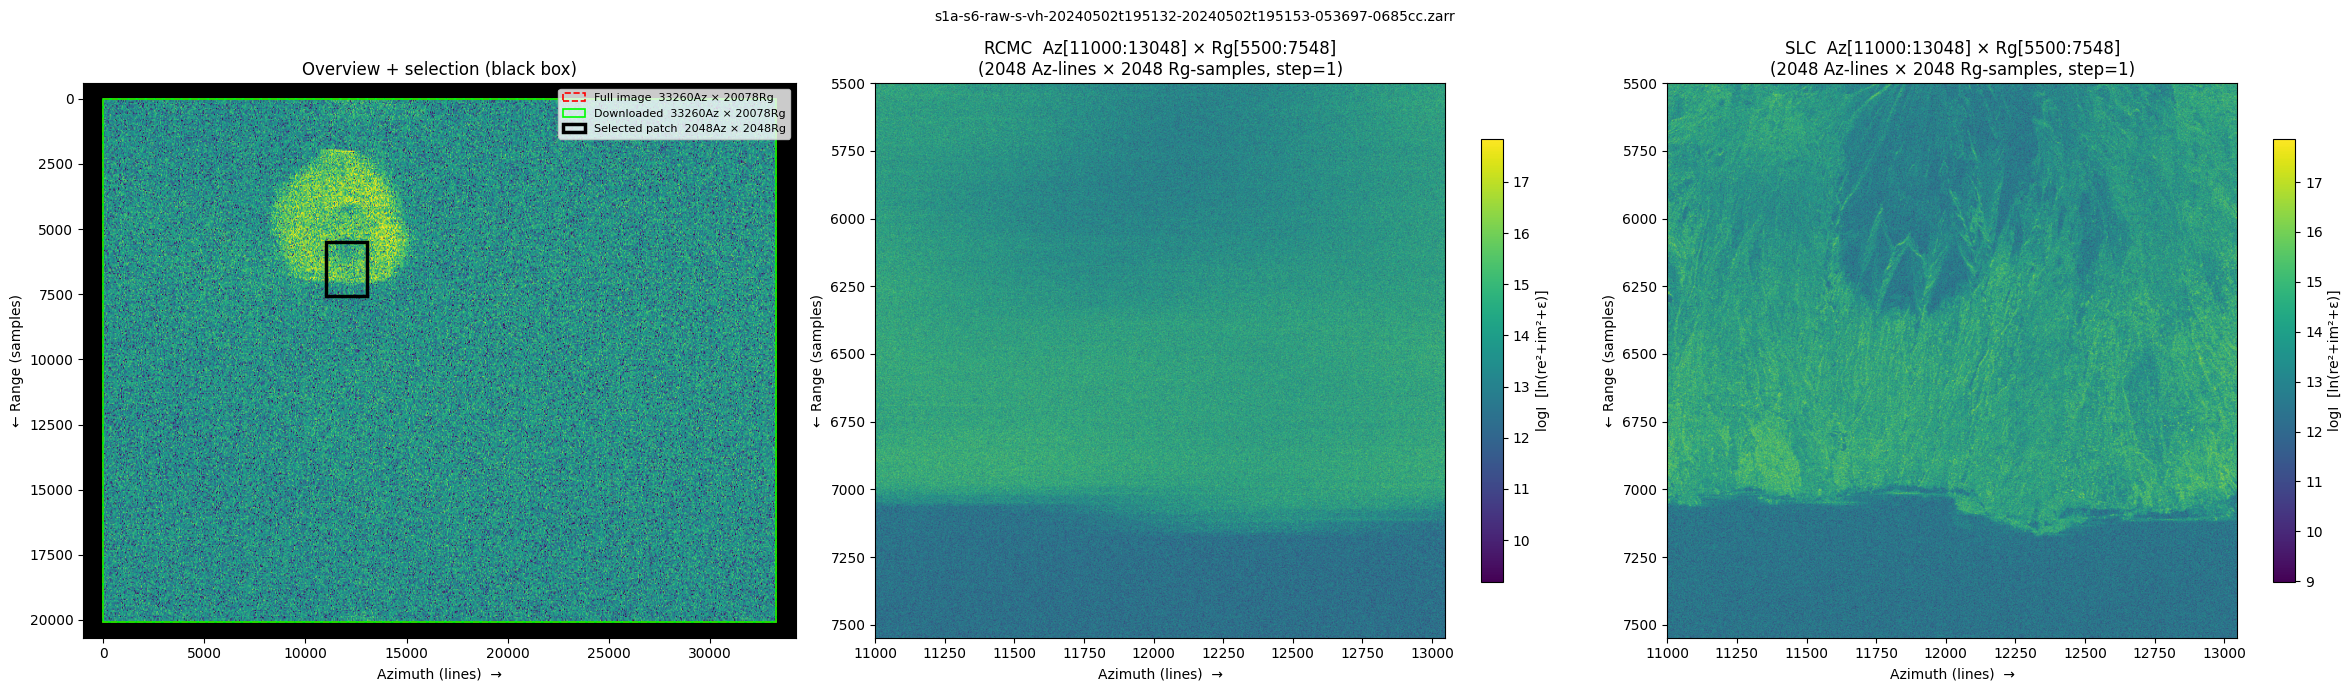

In [42]:
ZOOM_TARGET_PX = 2048   # target display size for zoomed patch

# ── Side-by-side: overview + patch box  |  RCMC zoom  |  SLC zoom ────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# ── Left: overview + patch rectangle ─────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("black")
ax.imshow(
    logI_overview.T,
    cmap="viridis",
    vmin=ov_vmin, vmax=ov_vmax,
    origin="upper",
    extent=[az_dl_start, az_dl_stop, rg_dl_stop, rg_dl_start],
    aspect="auto",
)
ax.add_patch(mpatches.Rectangle(
    (0, 0), full_az, full_rg,
    fill=False, edgecolor="red", linewidth=1.2, linestyle="--",
    label=f"Full image  {full_az}Az × {full_rg}Rg",
))
ax.add_patch(mpatches.Rectangle(
    (az_dl_start, rg_dl_start), az_dl, rg_dl,
    fill=False, edgecolor="lime", linewidth=1.2,
    label=f"Downloaded  {az_dl}Az × {rg_dl}Rg",
))
ax.add_patch(mpatches.Rectangle(
    (AZ_START, RG_START), az_patch, rg_patch,
    fill=False, edgecolor="black", linewidth=2.5,
    label=f"Selected patch  {az_patch}Az × {rg_patch}Rg",
))
ax.set_xlim(-full_az * 0.03, full_az * 1.03)
ax.set_ylim(full_rg * 1.03, -full_rg * 0.03)
ax.set_xlabel("Azimuth (lines)  →")
ax.set_ylabel("← Range (samples)")
ax.set_title("Overview + selection (black box)")
ax.legend(loc="upper right", fontsize=8)

# ── Middle: RCMC zoom ─────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("black")
_zoom_step = find_optimal_step_size(az_patch, rg_patch, ZOOM_TARGET_PX)
_zoom_data = store_rcmc[AZ_START : AZ_END : _zoom_step,
                         RG_START : RG_END : _zoom_step]
logI_zoom  = np.log(np.real(_zoom_data)**2 + np.imag(_zoom_data)**2 + EPS)
z_mu, z_sigma = logI_zoom.mean(), logI_zoom.std()
del _zoom_data
gc.collect()

im2 = ax2.imshow(
    logI_zoom.T,                  # (Rg_sub, Az_sub): x=Az, y=Rg
    cmap="viridis",
    vmin=z_mu - 3 * z_sigma, vmax=z_mu + 3 * z_sigma,
    origin="upper",
    extent=[AZ_START, AZ_END, RG_END, RG_START],
    aspect="auto",
)
plt.colorbar(im2, ax=ax2, label="logI  [ln(re²+im²+ε)]", shrink=0.8)
ax2.set_xlim(AZ_START, AZ_END)   # Az=0 on the left (no inversion)
ax2.set_ylim(RG_END, RG_START)   # Rg=0 at the top (y inverted via set_ylim)
ax2.set_xlabel("Azimuth (lines)  →")
ax2.set_ylabel("← Range (samples)")
ax2.set_title(
    f"RCMC  Az[{AZ_START}:{AZ_END}] × Rg[{RG_START}:{RG_END}]\n"
    f"({az_patch} Az-lines × {rg_patch} Rg-samples, step={_zoom_step})"
)

# ── Right: SLC (az-compressed) zoom ──────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("black")
_slc_data = store_az[AZ_START : AZ_END : _zoom_step,
                      RG_START : RG_END : _zoom_step]
logI_slc  = np.log(np.real(_slc_data)**2 + np.imag(_slc_data)**2 + EPS)
s_mu, s_sigma = logI_slc.mean(), logI_slc.std()
del _slc_data
gc.collect()

im3 = ax3.imshow(
    logI_slc.T,
    cmap="viridis",
    vmin=s_mu - 3 * s_sigma, vmax=s_mu + 3 * s_sigma,
    origin="upper",
    extent=[AZ_START, AZ_END, RG_END, RG_START],
    aspect="auto",
)
plt.colorbar(im3, ax=ax3, label="logI  [ln(re²+im²+ε)]", shrink=0.8)
ax3.set_xlim(AZ_START, AZ_END)
ax3.set_ylim(RG_END, RG_START)
ax3.set_xlabel("Azimuth (lines)  →")
ax3.set_ylabel("← Range (samples)")
ax3.set_title(
    f"SLC  Az[{AZ_START}:{AZ_END}] × Rg[{RG_START}:{RG_END}]\n"
    f"({az_patch} Az-lines × {rg_patch} Rg-samples, step={_zoom_step})"
)

plt.suptitle(zpath.name, fontsize=10)
plt.tight_layout()
plt.show()


In [43]:
# ── Save patch selection ──────────────────────────────────────────────────────
selection = {
    "product":     str(zpath),
    "part":        _entry.get("part", Path(SELECTED_FILE).parent.name),
    "date":        _entry.get("date", ""),
    "rcmc_shape":  _entry.get("rcmc_shape"),
    "az_start":    AZ_START,
    "az_end":      AZ_END,
    "rg_start":    RG_START,
    "rg_end":      RG_END,
    "az_lines":    az_patch,
    "rg_samples":  rg_patch,
}

sel_path = DATA_DIR / "selected_patch.json"
with open(sel_path, "w") as fh:
    json.dump(selection, fh, indent=2)

print(f"✓ Saved to {sel_path.relative_to(root)}")
print()
print(f"  Patch size : {az_patch} Az-lines × {rg_patch} Rg-samples")
print()
print("─── Config snippet for F14 fixed-patch callback ───────────────────")
print(f"  patch_product  : \"{selection['product']}\"")
print(f"  patch_az_start : {AZ_START}")
print(f"  patch_rg_start : {RG_START}")
print(f"  patch_az_lines : {az_patch}")
print(f"  patch_rg_samples: {rg_patch}")


✓ Saved to data/selected_patch.json

  Patch size : 2048 Az-lines × 2048 Rg-samples

─── Config snippet for F14 fixed-patch callback ───────────────────
  patch_product  : "/mnt/vitisAI/Vitis-AI/MAYA_DC/data/TEST/FOCUSED/s1a-s6-raw-s-vh-20240502t195132-20240502t195153-053697-0685cc.zarr"
  patch_az_start : 11000
  patch_rg_start : 5500
  patch_az_lines : 2048
  patch_rg_samples: 2048


---
## 9 · Patch Statistics & Amplitude Histogram

Load the selected patch at full resolution and display its amplitude distribution.
This confirms the patch is free from NaN / zero-fill artefacts before using it as a fixed reference.

Loading patch [11000:13048, 5500:7548] at full resolution...
  Size: 2048 Az × 2048 Rg = 4.19 M pixels  (~64.0 MB each)

               RCMC |·|       RCMC logI         SLC |·|        SLC logI
────────────────────────────────────────────────────────────────────────
  min            0.5437         -1.1855           0.458         -1.5151
  max              6272         17.4876       1.806e+04         19.6024
  mean             1070         13.5112            1042         13.4255
  std             666.1          1.4451           699.8          1.4823
✓  RCMC zero pixels: 0.00%
✓  SLC zero pixels: 0.00%


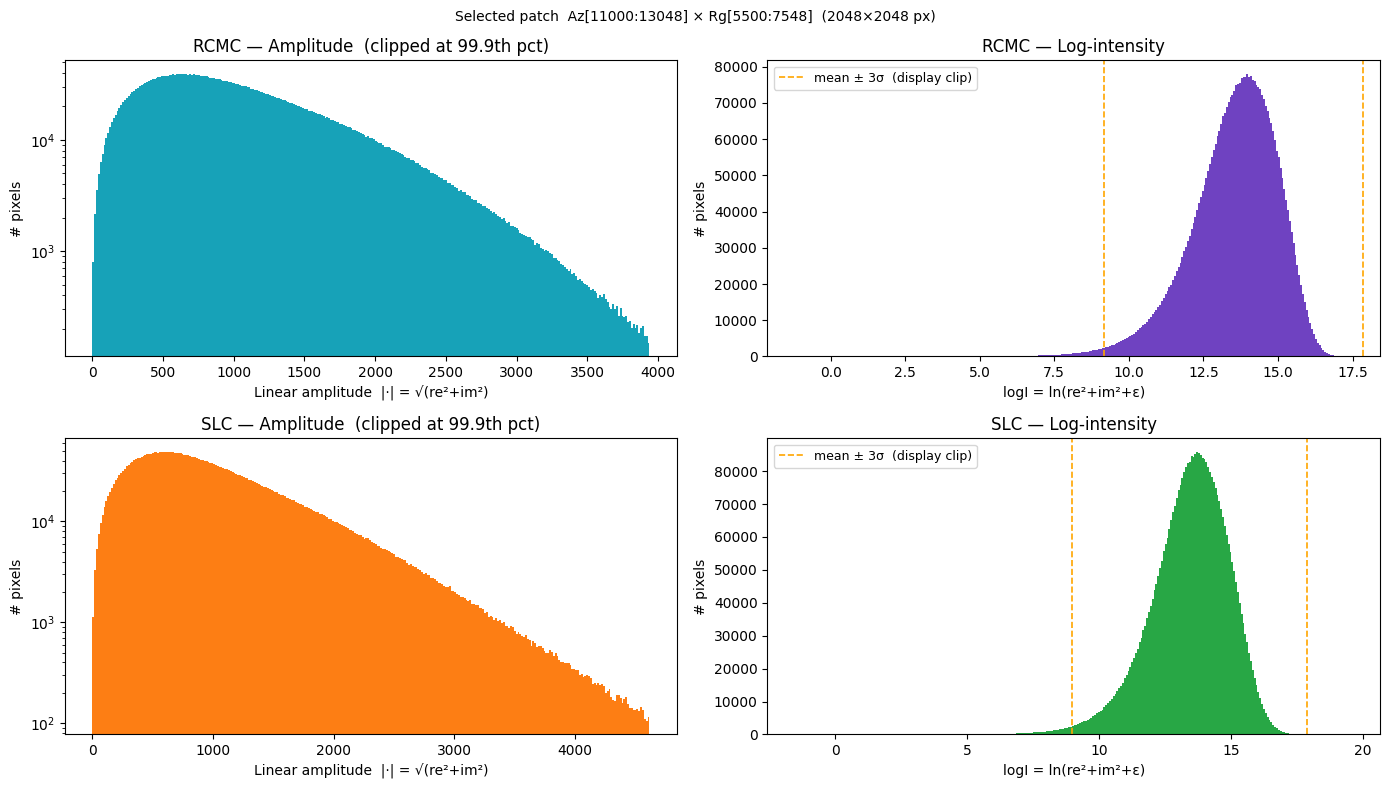

2573

In [44]:
_mem_mb = az_patch * rg_patch * 16 / 1024**2
print(f"Loading patch [{AZ_START}:{AZ_END}, {RG_START}:{RG_END}] at full resolution...")
print(f"  Size: {az_patch} Az × {rg_patch} Rg = {az_patch * rg_patch / 1e6:.2f} M pixels  (~{_mem_mb:.1f} MB each)")

# ── Load RCMC ─────────────────────────────────────────────────────────────────
_patch_rcmc = store_rcmc[AZ_START : AZ_END, RG_START : RG_END]
_re = np.real(_patch_rcmc).astype(np.float64)
_im = np.imag(_patch_rcmc).astype(np.float64)
_amp_rcmc  = np.sqrt(_re**2 + _im**2)
_logI_rcmc = np.log(_re**2 + _im**2 + EPS)
del _patch_rcmc, _re, _im
gc.collect()

# ── Load SLC ──────────────────────────────────────────────────────────────────
_patch_slc = store_az[AZ_START : AZ_END, RG_START : RG_END]
_re = np.real(_patch_slc).astype(np.float64)
_im = np.imag(_patch_slc).astype(np.float64)
_amp_slc  = np.sqrt(_re**2 + _im**2)
_logI_slc = np.log(_re**2 + _im**2 + EPS)
del _patch_slc, _re, _im
gc.collect()

# ── Text statistics ────────────────────────────────────────────────────────────
print(f"\n{'':8} {'RCMC |·|':>14}  {'RCMC logI':>14}  {'SLC |·|':>14}  {'SLC logI':>14}")
print("─" * 72)
for name, ra, rl, sa, sl in [
    ("min",  _amp_rcmc.min(),  _logI_rcmc.min(),  _amp_slc.min(),  _logI_slc.min()),
    ("max",  _amp_rcmc.max(),  _logI_rcmc.max(),  _amp_slc.max(),  _logI_slc.max()),
    ("mean", _amp_rcmc.mean(), _logI_rcmc.mean(), _amp_slc.mean(), _logI_slc.mean()),
    ("std",  _amp_rcmc.std(),  _logI_rcmc.std(),  _amp_slc.std(),  _logI_slc.std()),
]:
    print(f"  {name:<6} {ra:>14.4g}  {rl:>14.4f}  {sa:>14.4g}  {sl:>14.4f}")

for label, _amp in [("RCMC", _amp_rcmc), ("SLC", _amp_slc)]:
    _zero_frac = (_amp == 0).mean()
    if _zero_frac > 0.01:
        print(f"\n⚠  {label}: {100*_zero_frac:.1f}% of pixels are exactly zero "
              f"(likely non-downloaded chunks inside the patch boundary).")
    else:
        print(f"✓  {label} zero pixels: {100*_zero_frac:.2f}%")

# ── Histograms (2 × 2: amplitude | logI  for RCMC and SLC) ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── Row 0: RCMC ───────────────────────────────────────────────────────────────
ax = axes[0, 0]
_amp_clip = _amp_rcmc[_amp_rcmc < np.percentile(_amp_rcmc, 99.9)]
ax.hist(_amp_clip.ravel(), bins=300, color="#17a2b8", edgecolor="none")
ax.set_xlabel("Linear amplitude  |·| = √(re²+im²)")
ax.set_ylabel("# pixels")
ax.set_title("RCMC — Amplitude  (clipped at 99.9th pct)")
ax.set_yscale("log")

ax = axes[0, 1]
ax.hist(_logI_rcmc.ravel(), bins=300, color="#6f42c1", edgecolor="none")
ax.axvline(_logI_rcmc.mean() - 3 * _logI_rcmc.std(), color="orange",
           linestyle="--", linewidth=1.2, label="mean ± 3σ  (display clip)")
ax.axvline(_logI_rcmc.mean() + 3 * _logI_rcmc.std(), color="orange",
           linestyle="--", linewidth=1.2)
ax.set_xlabel("logI = ln(re²+im²+ε)")
ax.set_ylabel("# pixels")
ax.set_title("RCMC — Log-intensity")
ax.legend(fontsize=9)

# ── Row 1: SLC ────────────────────────────────────────────────────────────────
ax = axes[1, 0]
_slc_amp_clip = _amp_slc[_amp_slc < np.percentile(_amp_slc, 99.9)]
ax.hist(_slc_amp_clip.ravel(), bins=300, color="#fd7e14", edgecolor="none")
ax.set_xlabel("Linear amplitude  |·| = √(re²+im²)")
ax.set_ylabel("# pixels")
ax.set_title("SLC — Amplitude  (clipped at 99.9th pct)")
ax.set_yscale("log")

ax = axes[1, 1]
ax.hist(_logI_slc.ravel(), bins=300, color="#28a745", edgecolor="none")
ax.axvline(_logI_slc.mean() - 3 * _logI_slc.std(), color="orange",
           linestyle="--", linewidth=1.2, label="mean ± 3σ  (display clip)")
ax.axvline(_logI_slc.mean() + 3 * _logI_slc.std(), color="orange",
           linestyle="--", linewidth=1.2)
ax.set_xlabel("logI = ln(re²+im²+ε)")
ax.set_ylabel("# pixels")
ax.set_title("SLC — Log-intensity")
ax.legend(fontsize=9)

plt.suptitle(
    f"Selected patch  Az[{AZ_START}:{AZ_END}] × Rg[{RG_START}:{RG_END}]"
    f"  ({az_patch}×{rg_patch} px)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

del _amp_rcmc, _logI_rcmc, _amp_slc, _logI_slc, _amp_clip, _slc_amp_clip
gc.collect()
